In [ ]:

import os
import re 

from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import google.auth
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
from googleapiclient.http import MediaFileUpload

import duckdb
import pandas as pd
import pygsheets
# gspread
from pygsheets.exceptions import SpreadsheetNotFound


import math

from sqlalchemy import create_engine

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [ ]:
# carpeta donde está el notebook
base_dir = Path.cwd().parent
load_dotenv(base_dir)

SHEET_INSPECCIONES_ID = os.getenv('SHEET_INSPECCIONES_ID')
SHEET_DISTRIBUCIONES_ID = os.getenv('SHEET_DISTRIBUCIONES_ID')

In [ ]:
def max_rows(num):
    pd.set_option('display.max_rows',num)
    return f"Numero maximo de filas: {num}"

In [ ]:
def max_cols(num):
    pd.set_option('display.max_columns',num)
    return f"Numero maximo de columnas: {num}"

In [ ]:
max_rows(150)
max_cols(25)

In [ ]:
def guardar_en_sheets(gc, df, sheet_id, nombre_hoja='(sin nombre)', worksheet_index=0):
    """
    Guarda un DataFrame en una hoja de Google Sheets existente, sobrescribiendo su contenido.

    Parámetros:
        gc              : cliente de pygsheets ya autenticado
        df              : DataFrame de pandas a guardar
        sheet_id        : ID del spreadsheet (normalmente sacado de os.getenv(...))
        nombre_hoja     : nombre descriptivo solo para los mensajes de log/error
        worksheet_index : índice de la pestaña dentro del spreadsheet (0 = primera)

    Regresa:
        True si se guardó correctamente, False si hubo cualquier error.
    """
    try:
        if not sheet_id:
            raise ValueError(
                f"El ID de '{nombre_hoja}' no está definido: revisa tu .env y que load_dotenv() se haya corrido."
            )

        sh = gc.open_by_key(sheet_id)
        print(f"[{nombre_hoja}] Escribiendo en: {sh.title} — {sh.url}")

        wks = sh.worksheet_by_index() if False else sh[worksheet_index]  # ver nota abajo
        wks.clear(fields='*')
        wks.set_dataframe(
            df=df,
            start=(1, 1),
            copy_index=True,
            copy_head=True,
            fit=True
        )
        print(f"✅ [{nombre_hoja}] Guardado correctamente ({len(df)} filas)")
        return True

    except ValueError as e:
        print(f"❌ [{nombre_hoja}] Configuración incompleta: {e}")

    except SpreadsheetNotFound:
        print(f"❌ [{nombre_hoja}] No se encontró la hoja con ID '{sheet_id}'. Verifica que el ID sea correcto.")

    except HttpError as e:
        status = e.resp.status if hasattr(e, 'resp') else None
        if status == 403:
            print(f"❌ [{nombre_hoja}] Sin permiso: comparte la hoja como Editor con la cuenta de servicio.")
        elif status == 429:
            print(f"❌ [{nombre_hoja}] Límite de peticiones a la API alcanzado. Espera un momento y reintenta.")
        else:
            print(f"❌ [{nombre_hoja}] Error de la API de Google (status {status}): {e}")

    except Exception as e:
        print(f"❌ [{nombre_hoja}] Error inesperado: {type(e).__name__}: {e}")

    return False

In [ ]:
def calcular_rpm_por_grupo(df_inspecciones, tabla_grupos, rpm_col='MAXRPMDIESEL', random_state=None):
    """
    Para cada grupo (Marca/Submarca/Modelo) en tabla_grupos, toma una muestra aleatoria
    de tamaño Req_Population sobre df_inspecciones y calcula media, mediana y desviación
    estándar de rpm_col.

    Regresa una copia de tabla_grupos con las columnas rpm_mean, rpm_median, rpm_std agregadas.
    """
    resultados = []

    for idx in tabla_grupos.index:
        submarca = tabla_grupos.loc[idx, 'Submarca']
        modelo = tabla_grupos.loc[idx, 'Modelo']
        n_muestra = int(tabla_grupos.loc[idx, 'Req_Population'])

        subset = df_inspecciones.where(
            (df_inspecciones['Submarca'] == submarca) & (df_inspecciones['Modelo'] == modelo)
        ).dropna(how='all')

        if subset.empty:
            print(f"⚠️ Sin datos para {submarca} {modelo}, se omite.")
            resultados.append((idx, np.nan, np.nan, np.nan))
            continue

        # Si la muestra requerida es mayor a los datos disponibles, se toma el máximo posible
        n_real = min(n_muestra, len(subset))
        muestra = subset.sample(n_real, random_state=random_state)[rpm_col]

        resultados.append((
            idx,
            muestra.median(),
            math.ceil(muestra.mean()),
            round(muestra.std(ddof=1), 2) if n_real > 1 else np.nan
        ))

    data_rpm = pd.DataFrame(resultados, columns=['index', 'rpm_median', 'rpm_mean', 'rpm_std']).set_index('index')
    return tabla_grupos.join(data_rpm)

In [ ]:
def resumen_rpm_por_submarca(df_inspecciones, tabla_grupos, random_state=None):
    detalle = calcular_rpm_por_grupo(df_inspecciones, tabla_grupos, random_state=random_state)

    detalle['Population'] = pd.to_numeric(detalle['Population'], errors='coerce')
    detalle['rpm_mean'] = pd.to_numeric(detalle['rpm_mean'], errors='coerce')

    resumen = (
        detalle.dropna(subset=['rpm_mean', 'Population'])
        .groupby('Submarca')
        .apply(lambda g: pd.Series({
            'rpm_mean_ponderada': np.average(g['rpm_mean'], weights=g['Population']),
            'modelo_referencia': g.loc[g['Population'].idxmax(), 'Modelo'],
            'n_modelos': len(g)
        }), include_groups=False)
        .reset_index()
        .sort_values('rpm_mean_ponderada', ascending=False)
    )

    return detalle, resumen

In [ ]:
def graficar_rpm_por_submarca(resumen, guardar=False):
    fecha_actual = datetime.now().strftime('%d-%b-%Y %H:%M')

    fig, ax = plt.subplots(figsize=(12, 6))
    barras = sns.barplot(data=resumen, x='Submarca', y='rpm_mean_ponderada', ax=ax, palette='viridis')

    for i, row in resumen.reset_index(drop=True).iterrows():
        ax.text(
            i, row['rpm_mean_ponderada'] + 20,
            f"{row['rpm_mean_ponderada']:.0f} rpm\n({row['modelo_referencia']})",
            ha='center', fontsize=8
        )

    ax.set_title(f"Media de RPM por Submarca — actualizado {fecha_actual}")
    ax.set_xlabel('Submarca')
    ax.set_ylabel('RPM promedio')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if guardar:
        plt.savefig(f"rpm_por_submarca_{datetime.now().strftime('%Y%m%d')}.png", dpi=150)

    plt.show()

In [ ]:
creds_file = base_dir / "certs" / "GCPservice.json"
#-dbg-print(creds_file)

# acceder a Google Sheets
gc = pygsheets.authorize(service_file=str(creds_file))

In [65]:
# Cargamos de drive el archivo de Google Sheets que contiene los datos de las pruebas vehiculares (inspecciones_disese_api)
# Abre la hoja usando el ID es más seguro y rápido
sh = gc.open_by_key(SHEET_INSPECCIONES_ID)

# Selecciona la primera pestaña
wks = sh.sheet1

# Descarga los datos al DataFrame de Pandas
df_pytsh = wks.get_as_df(has_header=True)

# Muestra las primeras filas para confirmar que funcionó
df_pytsh.head()


,Centro,Serie,Placa,Linea,Fecha,TiempoEspera,InicioS1,FinS1,TecnicoS1,InicioS2,FinS2,TecnicoS2,...,Marca,SubMarca,Servicio,Cilindros,Carroceria,MetodoPrueba,TEMP_MOT,MIN_RPM_DIESEL,MAX_RPM_DIESEL,OPACIDAD,PBV,TipoPrueba
0,0,VF37R9HE1HJ582971,JV68939,2,2024-01-29 18:10:00,15,2024-01-29 18:19:00,2024-01-29 18:20:00,Jonhatan Escoto Enriquez,2024-01-29 18:20:00,2024-01-29 18:26:00,Jonhatan Escoto Enriquez,...,PEUGEOT,PARTNER HDI,SERVICIO DE CARGA,4 cil,VEHICULO UTILITARIO DEPORTIVO (SUV),Opacidad,96,748,4852,1.06,1,
1,0,MMBNG45K0FDZ00122,JT78273,2,2024-01-29 14:29:00,18,2024-01-29 14:39:00,2024-01-29 14:39:00,Jonhatan Escoto Enriquez,2024-01-29 14:39:00,2024-01-29 14:47:00,Erick Hernandez Rodriguez,...,MITSUBISHI,L200 TDI,SERVICIO DE CARGA,4 cil,PICKUP,Opacidad,92,701,5028,0.86,1,
2,0,VF3VFAHX1JZ001396,JX05500,2,2024-01-29 9:33:00,10,2024-01-29 9:36:00,2024-01-29 9:36:00,Jose de Jesus Guzman Nuñez,2024-01-29 9:36:00,2024-01-29 9:43:00,Jose de Jesus Guzman Nuñez,...,PEUGEOT,EXPERT VU,SERVICIO DE CARGA,4 cil,PANEL / VAN,Opacidad,287,747,3685,0.01,1,
3,0,VF37R9HE2HJ520592,JX17670,2,2024-01-25 10:11:00,16,2024-01-25 10:13:00,2024-01-25 10:15:00,Isaac Martinez Gonzalez,2024-01-25 10:15:00,2024-01-25 10:28:00,Isaac Martinez Gonzalez,...,PEUGEOT,PARTNER HDI,SERVICIO DE CARGA,4 cil,VEHICULO UTILITARIO DEPORTIVO (SUV),Opacidad,93,751,4784,0.51,1,
4,0,WV1CDASE3KX001661,JW42261,2,2024-01-25 9:48:00,14,2024-01-25 9:54:00,2024-01-25 9:54:00,Angel Ernesto Vargas Aguirre,2024-01-25 9:54:00,2024-01-25 10:01:00,Angel Ernesto Vargas Aguirre,...,VW,CADDY 2.0L TDI,SERVICIO DE CARGA,4 cil,VEHICULO UTILITARIO DEPORTIVO (SUV),Opacidad,91,830,2588,0.72,1,


In [66]:
df_pytsh.columns
df_pytsh.info() 

<class 'pandas.DataFrame'>
RangeIndex: 89561 entries, 0 to 89560
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Centro              89561 non-null  int64 
 1   Serie               89561 non-null  object
 2   Placa               89561 non-null  object
 3   Linea               89561 non-null  int64 
 4   Fecha               89561 non-null  str   
 5   TiempoEspera        89561 non-null  int64 
 6   InicioS1            89561 non-null  str   
 7   FinS1               89561 non-null  str   
 8   TecnicoS1           89561 non-null  str   
 9   InicioS2            89561 non-null  str   
 10  FinS2               89561 non-null  str   
 11  TecnicoS2           89561 non-null  str   
 12  TecnicoEgreso       89561 non-null  str   
 13  Resultado           89561 non-null  str   
 14  MotivoFracaso       89561 non-null  str   
 15  NumeroTransaccion   89561 non-null  object
 16  Tipo                89561 non-nul

In [67]:

# Cargamos de drive el archivo CSV de la consulta ya cruzada con los datos de WEP de los rangos para las pruebas (distribuciones_rpms)
# Abre la hoja usando el ID es más seguro y rápido
sh = gc.open_by_key(SHEET_DISTRIBUCIONES_ID)

# Selecciona la primera pestaña
wks = sh.sheet1

# Descarga los datos al DataFrame de Pandas
df_wep = wks.get_as_df(has_header=True)

# Muestra las primeras filas para confirmar que funcionó
df_wep.columns
df_wep.info()
df_wep.head()


<class 'pandas.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       1929 non-null   int64 
 1   marca.PANTALLA           1929 non-null   str   
 2   submarca.PANTALLA        1929 non-null   object
 3   motor_submarca.PANTALLA  1929 non-null   str   
 4   FuelTypeName             1929 non-null   str   
 5   ALIMCOMB.PANTALLA        1929 non-null   str   
 6   POTMAXRPM                1929 non-null   int64 
 7   ANODESDE                 1929 non-null   int64 
 8   ANOHASTA                 1929 non-null   int64 
 9   isInactive               1929 non-null   int64 
 10  lastUpdate               1929 non-null   str   
dtypes: int64(5), object(1), str(5)
memory usage: 165.9+ KB


,ID,marca.PANTALLA,submarca.PANTALLA,motor_submarca.PANTALLA,FuelTypeName,ALIMCOMB.PANTALLA,POTMAXRPM,ANODESDE,ANOHASTA,isInactive,lastUpdate
0,377,FORD,ECONOLINE WAGON,DT(235 H.P./2700rpm),DIESEL,TURBOCARGADO,2700,1998,2007,0,01-abr-25
1,746,VW,GOLF TDI DIESEL,VW(115 H.P./4500rpm),DIESEL,TURBOCARGADO,4500,1998,2007,0,10-dic-23
2,757,VW,JETTA 1.9 TDI,VW(115 H.P./4500rpm),DIESEL,TURBOCARGADO,4500,1998,2007,0,10-dic-23
3,775,VW,BEETLE DIESEL,VW(115 H.P./4500rpm),DIESEL,TURBOCARGADO,4500,1999,2007,0,10-dic-23
4,781,VW,GOLF DIESEL,VW 1.6 L ASPIRACION NATURAL (/4500rpm),DIESEL,TURBOCARGADO,4500,1993,1997,0,10-dic-23


In [68]:
#df_wep = pd.read_sql_table('diesel_specs_feb_2023', con = con_wep)

In [69]:
df_pytsh.info()

<class 'pandas.DataFrame'>
RangeIndex: 89561 entries, 0 to 89560
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Centro              89561 non-null  int64 
 1   Serie               89561 non-null  object
 2   Placa               89561 non-null  object
 3   Linea               89561 non-null  int64 
 4   Fecha               89561 non-null  str   
 5   TiempoEspera        89561 non-null  int64 
 6   InicioS1            89561 non-null  str   
 7   FinS1               89561 non-null  str   
 8   TecnicoS1           89561 non-null  str   
 9   InicioS2            89561 non-null  str   
 10  FinS2               89561 non-null  str   
 11  TecnicoS2           89561 non-null  str   
 12  TecnicoEgreso       89561 non-null  str   
 13  Resultado           89561 non-null  str   
 14  MotivoFracaso       89561 non-null  str   
 15  NumeroTransaccion   89561 non-null  object
 16  Tipo                89561 non-nul

In [70]:
# ya no se encuentran estilo de vehiculo y transmision en el api
df_pytsh[['Combustible','Servicio','Cilindros']] = df_pytsh[['Combustible','Servicio','Cilindros']].astype('category')
#ToDo: pedir a wep carguen DIESELMARCA y SUBMARCADIÉSEL sean incluidos en las tablas de inspecciones 
#df_pytsh[['Marca','SubMarca','DIESELMARCA','SUBMARCADIÉSEL']] = df_pytsh[['Marca','SubMarca','DIESELMARCA','SUBMARCADIÉSEL']].astype('string') 
df_pytsh[['Marca','Submarca']] = df_pytsh[['Marca','SubMarca']].astype('string') 
# sincronizamos nombres
df_pytsh.rename(columns={'MAX_RPM_DIESEL':'MAXRPMDIESEL'}, inplace=True)

In [71]:
df_wep.info()

<class 'pandas.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       1929 non-null   int64 
 1   marca.PANTALLA           1929 non-null   str   
 2   submarca.PANTALLA        1929 non-null   object
 3   motor_submarca.PANTALLA  1929 non-null   str   
 4   FuelTypeName             1929 non-null   str   
 5   ALIMCOMB.PANTALLA        1929 non-null   str   
 6   POTMAXRPM                1929 non-null   int64 
 7   ANODESDE                 1929 non-null   int64 
 8   ANOHASTA                 1929 non-null   int64 
 9   isInactive               1929 non-null   int64 
 10  lastUpdate               1929 non-null   str   
dtypes: int64(5), object(1), str(5)
memory usage: 165.9+ KB


In [72]:
df_wep[['Marca','Submarca','submarcaDiesel']] = df_wep[['marca.PANTALLA','submarca.PANTALLA','motor_submarca.PANTALLA']].astype('string')

## Para definir pruebas diesel:
- Realizar cruce con Submarcas diesel presentes en tablas proporcionadas por WEP
- Filtrar con tipo de combustible = `DIESEL`


In [73]:
# Interseccion de lista de submarcas diesel verificadas con lista de submarcas diesel proporcionadas por wep

list_submarcas_vision = df_pytsh['Submarca'].unique()
list_submarcas_twep = df_wep['Submarca'].unique()

list_submarcas_inter = [value for value in list_submarcas_vision if value in list_submarcas_twep]

In [74]:
len(list_submarcas_inter)

675

**Se podria asumir que aquellas submarcas que no se encuentran en la interseccion de las pruebas vehiculares con las submarcas de tablas de WEP, son aquellas que presentan confusion al momento de elegir el registro para el tipo de combustible o que ya no existen en las tablas de WEP**

In [75]:
# Elementos del conjunto de pruebas diesel que no se encuentran en la interseccion
df_pytsh['Submarca'].where(~df_pytsh['Submarca'].isin(list_submarcas_inter)).dropna(how = 'all').value_counts().head(50)

Submarca
F-600                                872
D-600                                628
RANGER TDI 5CIL                      341
RANGER TDI 4CIL                      282
OTRO INTERNATIO/NAVISTAR PESADO      269
OTRO DINA PESADO                     248
531                                  236
NP300 TDI YD25                       233
3000                                 161
F-350                                148
OTRO MERCEDES BENZ PESADO            147
CRAFTER 2.0TDI                       146
OTRO PETERBILT PESADO                146
F-450                                142
F-250 PICK UP                        141
RAM 2500 PICK UP                     133
D-350                                108
OTRO FORD PESADO                     107
631                                   89
NP300                                 88
OTRO FREIGHTLINER PESADO              86
GOLF 2.0  TDI                         85
1000                                  83
TRANSIT                               79
HILUX  

In [76]:
df_pytsh_inter = df_pytsh.where(df_pytsh['Submarca'].isin(list_submarcas_inter) & (~df_pytsh['MAXRPMDIESEL'].isin([0,3999,5999]))).dropna(how = 'all')
df_pytsh_inter.shape

(58577, 35)

In [77]:
pop_table = pd.DataFrame(df_pytsh_inter[['Marca','Submarca','Modelo']].groupby(['Marca','Submarca','Modelo']).value_counts(ascending = False)).reset_index()

In [78]:
pop_table.columns

Index(['Marca', 'Submarca', 'Modelo', 'count'], dtype='str')

In [79]:
pop_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 4585 entries, 0 to 4584
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Marca     4585 non-null   string 
 1   Submarca  4585 non-null   string 
 2   Modelo    4585 non-null   float64
 3   count     4585 non-null   int64  
dtypes: float64(1), int64(1), string(2)
memory usage: 143.4 KB


In [80]:
pop_table.rename(columns = {'count':'Population'}, inplace = True)

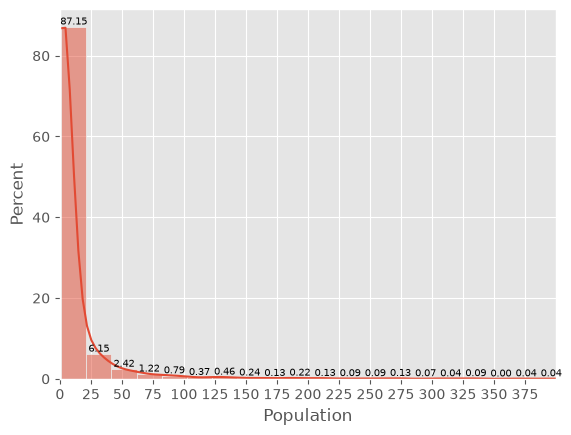

In [81]:
pop_data_hist = sns.histplot(data = pop_table['Population'].loc[pop_table['Population'] > 0],
                             binwidth = 20,
                             stat = 'percent',
                             kde = True,
                             )

pop_data_hist.set_xlim(0,400)
pop_data_hist.set_xticks(range(0,382,25))
for i in pop_data_hist.containers:
        pop_data_hist.bar_label(i, fontsize = 7, fmt = '%.2f')

In [82]:
pop_table['Population'].loc[pop_table['Population'] > 0].describe()

count    4585.000000
mean       12.775791
std        37.682892
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
max       690.000000
Name: Population, dtype: float64

In [83]:
Q3 = pop_table['Population'].loc[pop_table['Population'] > 0].quantile(0.75)

In [84]:
# Cuartil Q3 
pop_table['Population'].loc[pop_table['Population'] >= Q3]

4       13
6       12
9       58
10      12
12      10
        ..
4553     9
4554    20
4555    35
4556    25
4564    38
Name: Population, Length: 1201, dtype: int64

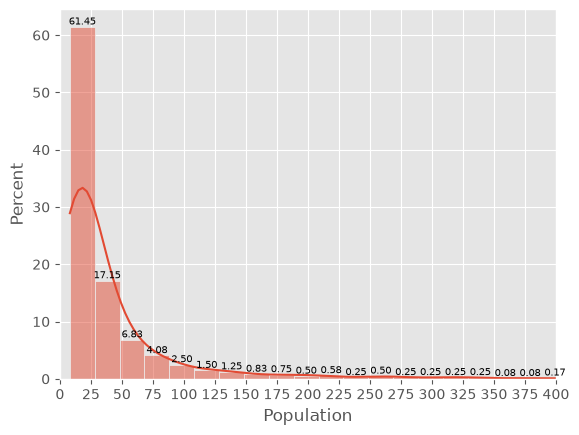

In [85]:
pop_data_hist = sns.histplot(data = pop_table['Population'].loc[pop_table['Population'] >= Q3],
                             binwidth = 20,
                             stat = 'percent',
                             kde = True,
                             )

pop_data_hist.set_xlim(0,400)
pop_data_hist.set_xticks(range(0,401,25))
for i in pop_data_hist.containers:
        pop_data_hist.bar_label(i, fontsize = 7, fmt = '%.2f')

In [86]:
pop_table.loc[pop_table['Population'] >= Q3].describe()

,Modelo,Population
count,1201.000000,1201.000000
mean,2015.691091,42.621149
std,6.675477,64.878698
min,1981.000000,8.000000
25%,2012.000000,12.000000
50%,2017.000000,21.000000
75%,2021.000000,42.000000
max,2025.000000,690.000000


In [87]:
# Dentro de conjunto de datos del Q3, analizar aquellos del Cuartil 3, sera denominado q3
q3 = pop_table['Population'].loc[pop_table['Population'] >= Q3].quantile(0.75)

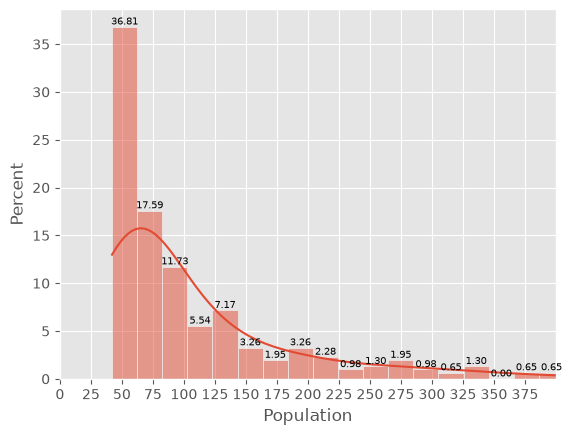

In [88]:
pop_data_hist = sns.histplot(data = pop_table['Population'].loc[pop_table['Population'] >= q3],
                             binwidth = 20,
                             stat = 'percent',
                             kde = True,
                             )

pop_data_hist.set_xlim(0,400)
pop_data_hist.set_xticks(range(0,381,25))
for i in pop_data_hist.containers:
        pop_data_hist.bar_label(i, fontsize = 7, fmt = '%.2f')

In [89]:
pop_table['Population'].loc[pop_table['Population'] >= q3].describe()

count    307.000000
mean     113.185668
std       97.734207
min       42.000000
25%       55.000000
50%       77.000000
75%      130.000000
max      690.000000
Name: Population, dtype: float64

In [90]:
pop_table['Population'].loc[pop_table['Population'] > q3].groupby(pd.cut(pop_table['Population'],[0,98,200,300,400])).count()

Population
(0, 98]       190
(98, 200]      67
(200, 300]     23
(300, 400]     12
Name: Population, dtype: int64

In [91]:
# Z-score: 80%:1.28, 85%:1.44, 90%:1.65, 95%:1.96, 99%:2.58 

Z = 2.576  # Z-score para 95% confidence level
σ = 5  # desviación estándar estimada
E = 1  # margen de error deseado
N = 1  # tamaño de población

list_pop = range(0,401,10)
# Calculate the required sample size
n = math.ceil((Z**2 * σ**2 * N) / ((Z**2 * σ**2) + (E**2 * (N-1))))
final = []
for pop in list_pop:
    result = math.ceil((Z**2 * σ**2 * pop) / ((Z**2 * σ**2) + (E**2 * (pop-1))))
    final.append(result)

print(list(zip(list_pop,final)))

sample_df = pd.DataFrame({'Pop':list_pop,'Sample':final})
#print(f"The required sample size is {n}")

[(0, 0), (10, 10), (20, 18), (30, 26), (40, 33), (50, 39), (60, 45), (70, 50), (80, 55), (90, 59), (100, 63), (110, 67), (120, 70), (130, 74), (140, 77), (150, 80), (160, 82), (170, 85), (180, 87), (190, 89), (200, 91), (210, 93), (220, 95), (230, 97), (240, 99), (250, 100), (260, 102), (270, 103), (280, 105), (290, 106), (300, 108), (310, 109), (320, 110), (330, 111), (340, 112), (350, 113), (360, 114), (370, 115), (380, 116), (390, 117), (400, 118)]


<Axes: xlabel='Pop', ylabel='Sample'>

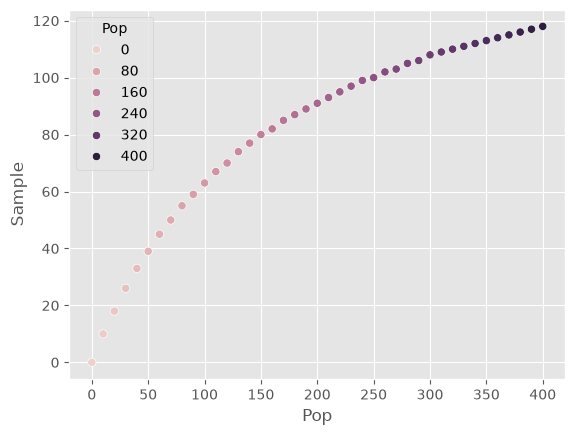

In [92]:
sns.scatterplot(y = sample_df['Sample'], x=sample_df['Pop'],hue=sample_df['Pop'])

### ~20% de las submarcas utilizadas durante pruebas (aquellas que tienen interseccion con las tablas de wep) tienen un tamanio de muestra de alrededor de 100 inspecciones, por fines practicos se trabajara con el 20% de los datos del Q3

- En pop_table con `Population` >= `90` asignar `Z_Score` = `2.576`
- En pop_table con `Population` >= `80` & <= `89` asignar `Z_Score` = `1.96`
- En pop_table con `Population` >= `54` & < `80` asignar `Z_Score` = `1.65`
- En pop_table con `Population` >= `27` & < `54` asignar `Z_Score` = `1.44`
- En pop_table de manera general asignar `E_Margin` = `1`
- En pop_table de manera general asignar `Std_Dev` = `5`
- En pop_table `Req_Population` se calcula de manera automatica

### Todo esto se hace para calcular el tamanio de muestra necesario para tomarlo como parametro de muestra aleatoria en cada submarca, ese tamanio de muestra se almacena en el atributo `Req_Population`, posteriormente habra otro atributo llamado `RPM_Median` en donde se almacenaran las medianas de RPM para cada submarca

In [93]:
pop_table['Z_Score'] = 0
pop_table['Std_Dev'] = 5
pop_table['E_Margin'] = 1

pop_table[['Z_Score','Std_Dev','E_Margin']] = pop_table[['Z_Score','Std_Dev','E_Margin']].astype('float64')

In [94]:
list_reg_99 = pop_table.loc[pop_table['Population'] >= 90].index
list_reg_95 = pop_table.loc[pop_table['Population'].between(80,89,inclusive='both')].index
list_reg_90 = pop_table.loc[pop_table['Population'].between(54,80,inclusive='both')].index
list_reg_85 = pop_table.loc[pop_table['Population'].between(27,53,inclusive='both')].index
current_working_regs = [list_reg_99,list_reg_95,list_reg_90,list_reg_85]
flattened_list = [item for sublist in current_working_regs for item in sublist]

In [95]:
pop_table.loc[list_reg_99,'Z_Score'] = 2.576
pop_table.loc[list_reg_95,'Z_Score'] = 1.96
pop_table.loc[list_reg_90,'Z_Score'] = 1.65
pop_table.loc[list_reg_85,'Z_Score'] = 1.44

In [96]:
# Req_Population se utilza como parametro para el tamanio de muestra aleatoria

pop_table['Req_Population'] = pop_table['Z_Score']**2 * pop_table['Std_Dev']**2 * pop_table['Population']\
                             / ((pop_table['Z_Score']**2 * pop_table['Std_Dev']**2)\
                             + (pop_table['E_Margin']**2 * (pop_table['Population']-1)))

In [97]:
pop_table.loc[pop_table['Population'] >= 27]

,Marca,Submarca,Modelo,Population,Z_Score,Std_Dev,E_Margin,Req_Population
9,AUDI,Q3 2.0TDI QUATTRO,2013.0,58,1.65,5.0,1.0,31.565217
13,AUDI,Q5 3.0TDI QUATTRO,2010.0,34,1.44,5.0,1.0,20.775106
63,CHEVROLET PESADO,KODIAK DIESEL,2004.0,46,1.44,5.0,1.0,24.624535
64,CHEVROLET PESADO,KODIAK DIESEL,2005.0,34,1.44,5.0,1.0,20.775106
65,CHEVROLET PESADO,KODIAK DIESEL,2006.0,34,1.44,5.0,1.0,20.775106
...,...,...,...,...,...,...,...,...
4498,VW PESADO,CRAFTER 2.0 TDI,2023.0,46,1.44,5.0,1.0,24.624535
4499,VW PESADO,CRAFTER 2.0 TDI,2024.0,30,1.44,5.0,1.0,19.238001
4537,VW PESADO,DELIVERY 6.160,2022.0,47,1.44,5.0,1.0,24.902698
4555,VW PESADO,DELIVERY 9.170,2022.0,35,1.44,5.0,1.0,21.136999


In [98]:
pop_table['Req_Population'] = pop_table['Req_Population'].fillna(0)

In [99]:
pop_table['Req_Population'] = pop_table['Req_Population'].apply(lambda x: math.ceil(x)) 

In [100]:
pop_table.rank(method='dense',numeric_only=True).sort_values(by = 'Population', ascending = False)

,Modelo,Population,Z_Score,Std_Dev,E_Margin,Req_Population
3399,68.0,187.0,5.0,1.0,1.0,78.0
1343,62.0,186.0,5.0,1.0,1.0,77.0
3400,69.0,185.0,5.0,1.0,1.0,76.0
4063,64.0,184.0,5.0,1.0,1.0,75.0
4302,64.0,183.0,5.0,1.0,1.0,74.0
...,...,...,...,...,...,...
51,35.0,1.0,1.0,1.0,1.0,1.0
76,47.0,1.0,1.0,1.0,1.0,1.0
74,39.0,1.0,1.0,1.0,1.0,1.0
3,59.0,1.0,1.0,1.0,1.0,1.0


In [101]:
pop_table['Ranking'] = pop_table['Population'].rank(method='dense',ascending=False)

In [102]:
data = pop_table.sort_values(by='Population',ascending=False)
data.index.name = 'group_id'

In [103]:
# Hoja donde se almacena el ranking de grupos de vehiculos diesel
SHEET_RANK_ID = os.getenv('SHEET_RANK_ID')

guardar_en_sheets(gc, data, SHEET_RANK_ID, 'ranking_grupos_diesel',0)


[ranking_grupos_diesel] Escribiendo en: diesel_rank — https://docs.google.com/spreadsheets/d/1xo7JqihFPcNdnoHYW971L15h09fbhKuNDJrQx26DmSI
✅ [ranking_grupos_diesel] Guardado correctamente (4585 filas)


True

#### Grafica de media de RPMs por submarca:

    - Toma el tamanio de muestra para hacer la seleccion aleatoria
    - Despliega la media de RPMs para esa submarca con el modelo correspondiente

In [104]:
data['Z_Score'].value_counts()

Z_Score
0.000    4092
1.440     258
2.576     126
1.650      89
1.960      20
Name: count, dtype: int64

In [105]:
data_work_indexes = data[['Marca','Submarca','Modelo','Population','Req_Population']].where((data['Z_Score'] != 0)).dropna(how = 'all').index.tolist()

In [106]:
data_2 = data[['Marca','Submarca','Modelo','Population','Req_Population','Z_Score','Ranking']].loc[data_work_indexes,]

In [107]:
data_2 = data_2.astype({
    'Modelo': 'int',
    'Ranking': 'int',
    'Population': 'int',
    'Req_Population': 'int'
})

In [108]:
print(data_2.dtypes)
data_2[['Population','Req_Population']].head()

Marca              string
Submarca           string
Modelo              int64
Population          int64
Req_Population      int64
Z_Score           float64
Ranking             int64
dtype: object


,Population,Req_Population
group_id,,
3399,690,134
1343,664,133
3400,577,130
4063,506,126
4302,499,125


In [109]:
detalle_rpm, resumen_submarca = resumen_rpm_por_submarca(df_pytsh_inter, data_2, random_state=42)
resumen_submarca

,Submarca,rpm_mean_ponderada,modelo_referencia,n_modelos
88,PARTNER TEPEE,4629.243697,2017.0,6.0
27,DUCATO 2.3L,4558.000000,2019.0,1.0
28,DUCATO 2.3L MULTIJET,4512.077419,2021.0,3.0
101,SPRINTER 516 (MAN/AUT) EURO V,4492.313830,2021.0,5.0
72,MANAGER,4472.538462,2020.0,2.0
107,TRAFIC 1.9MT,4437.000000,2008.0,1.0
0,208 HDI,4436.000000,2016.0,1.0
110,TRANSIT DIESEL,4430.057971,2009.0,4.0
10,500 1626,4364.000000,2020.0,1.0
85,PARTNER,4354.945698,2020.0,13.0


In [110]:
graficar_rpm_por_submarca(resumen_submarca)

NameError: name 'graficar_rpm_por_submarca' is not defined

In [ ]:
# data_2 queda con el detalle por Marca/Submarca/Modelo (incluye rpm_mean, rpm_median, rpm_std)
# para que las celdas siguientes (filtros, subida a Sheets, histogramas) sigan funcionando igual
data_2 = detalle_rpm
data_2

In [ ]:
data_2

In [ ]:
#data_2.to_csv('diesel_rpm_stats.csv',encoding='latin-1')

In [ ]:
data_2.where(
    (data_2['Submarca'] == 'L200 TDI')\
    & (data_2['Modelo'] == 2015))\
    .dropna(how = 'all')

### Actualizar gsheet de pop_table

In [ ]:
creds_file_pipeline = r'C:\PythonProjects\GCPserviceAccounts\drev-374720-4417086df6ad.json'

In [ ]:
gc_ppl = pygsheets.authorize(service_file=creds_file_pipeline)

In [ ]:
sh_pop = gc_ppl.open('pop_table')
wks_pop = sh_pop.sheet1

In [ ]:
wks_pop.clear(fields="*")

In [ ]:
wks_pop.set_dataframe(
    df=pop_table,
    start=(1,1),
    copy_index=False,
    copy_head=True,
    fit=True
)

### Actualizar gsheet de diesel_stats

In [ ]:
sh_stats = gc_ppl.open('diesel_stats')
wks_stats = sh_stats.sheet1

In [ ]:
wks_stats.clear(fields="*")

In [ ]:
wks_stats.set_dataframe(
    df=data_2,
    start=(1,1),
    copy_index=False,
    copy_head=True,
    fit=True
)

#### Actualizar gsheet de seleccion_motores

In [ ]:
sh_mot = gc_ppl.open('seleccion_motores')
wks_mot = sh_mot.sheet1

In [ ]:
seleccion_motores = pd.read_csv(r"C:\Users\Liam_\Downloads\seleccion_motores.csv")

In [ ]:
wks_mot.set_dataframe(
    df=seleccion_motores,
    start=(1,1),
    copy_index=False,
    copy_head=True,
    fit=True
)

### Crear imagenes de distribuciones 

In [ ]:
graph = sns.histplot(
    df_pytsh_inter.where(
        (df_pytsh_inter['Submarca'] == 'L200 TDI')\
            & (df_pytsh_inter['Modelo'] == 2020)
            )['MAXRPMDIESEL'],
            kde=True,
            bins=20,
            stat='count',
            element='bars',
            fill=True,
            color='#133250',
            cbar=False
            #kde_kws={'bw_adjust':0.25},
            )
graph.set_title("Distribución de inspecciones de\n<submarca> <modelo>\nen banda de RPMs")
graph.set_ylabel("Cantidad de inspecciones")
graph.set_xlabel("Revoluciones por minuto")

sns.set(rc = {"figure.figsize":(8,8)})

for i in graph.containers:  
    graph.bar_label(
        container = i,
        label_type = "edge")

#fig = graph.get_figure() 
#fig.savefig("graph.png")

In [ ]:
for vehicle in data_2.index:
    graph = sns.histplot(
        df_pytsh_inter.where(
            (df_pytsh_inter['Submarca'] == data_2.loc[vehicle,'Submarca'])\
                & (df_pytsh_inter['Modelo'] == data_2.loc[vehicle,'Modelo'])
                )['MAXRPMDIESEL'],
                kde=True,
                bins=20,
                stat='count',
                element='bars',
                fill=True,
                color='#133250'
                #kde_kws={'bw_adjust':0.25},
                )
    graph.set_title(f"Distribución de inspecciones de\n{data_2.loc[vehicle,'Submarca']} {data_2.loc[vehicle,'Modelo']}\nen banda de RPMs")
    graph.set_ylabel("Cantidad de inspecciones")
    graph.set_xlabel("Revoluciones por minuto")

    sns.set(rc = {"figure.figsize":(8,8)})

    for i in graph.containers:  
        graph.bar_label(
            container = i,
            label_type = "edge")
    fig = graph.get_figure() 
    fig.savefig(f"Imagenes/{data_2.loc[vehicle,'Submarca'].replace('/','_')},{data_2.loc[vehicle,'Modelo']}.png")
    plt.clf()

### Subir/Actualizar imagenes de distribuciones a carpeta de google drive

In [ ]:
def get_file_id(service, folder_id, filename):
    response = service.files().list(q=f"'{folder_id}' in parents and name='{filename}'").execute()
    files = response.get('files', [])
    
    if files:
        return files[0]['id']
    else:
        return None
    

def upload_folder_to_drive(folder_path, target_folder_id):
    creds, _ = google.auth.load_credentials_from_file(
        filename="C:\\PythonProjects\\GCPserviceAccounts\\drev-374720-4417086df6ad.json" # Anadir a variable local
    )
    
    try:
        # Create Google Drive API client
        service = build("drive", "v3", credentials=creds)

        # Iterate through files in the local folder
        for filename in os.listdir(folder_path):

            file_path = os.path.join(folder_path, filename)

            # Get the file ID if it exists in the target folder
            file_id = get_file_id(service, target_folder_id, filename)

            # Define file metadata with parent folder ID
            file_metadata = {
                "name": filename,
                "mimeType": "PNG",  
                "parents": [target_folder_id] # parents cuando no hay informacion inicial
            }

            # Create media file upload
            media = MediaFileUpload(file_path, resumable=True)

            if file_id:

                file_metadata = {
                "name": filename,
                "mimeType": "PNG",  
                "addParents": [target_folder_id]
                }
                # If the file exists, update it
                file = (
                    service.files()
                    .update(fileId=file_id, body=file_metadata, media_body=media, fields="id")
                    .execute()
                )
                print(f'File with ID: "{file.get("id")}" has been updated in folder with ID: "{target_folder_id}".')

            else:

                file_metadata = {
                "name": filename,
                "mimeType": "PNG",  
                "parents": [target_folder_id]
                }
                # If the file doesn't exist, create it
                file = (
                    service.files()
                    .create(body=file_metadata, media_body=media, fields="id")
                    .execute()
                )
                print(f'File with ID: "{file.get("id")}" has been uploaded to folder with ID: "{target_folder_id}".')
            
    except HttpError as error:
        print(f"An error occurred: {error}")

folder_path = "Imagenes"
target_folder_id = "1VTUfbDEhbBbHtOYSAZfTeVe3mvqx8XQo" # Variable de entorno
image_metadata = upload_folder_to_drive(folder_path, target_folder_id)

### Conseguir metadatos de imagenes de graficas y actulizar gsheet de distribuciones_rpms

In [ ]:
def get_images_metadata(folder_id: str) -> list:
    creds, _ = google.auth.load_credentials_from_file(
        filename="C:\\PythonProjects\\GCPserviceAccounts\\drev-374720-4417086df6ad.json"
    )
    service = build('drive', 'v3', credentials=creds)
    
    response = service.files().list(q=f"'{folder_id}' in parents and mimeType='image/png'",
                                    pageSize=100).execute()

    files = response.get('files', [])
    next_page_token = response.get('nextPageToken')

    while next_page_token:
        response = service.files().list(q=f"'{folder_id}' in parents and mimeType='image/png'",
                                        pageSize=100,
                                        pageToken=next_page_token).execute()
        files.extend(response.get('files', []))
        next_page_token = response.get('nextPageToken')

    return files

image_metadata = get_images_metadata('1VTUfbDEhbBbHtOYSAZfTeVe3mvqx8XQo') # variable de entorno

In [ ]:
list_image_metadata = []
for pos in range(0,len(image_metadata)):
    list_image_metadata.append((image_metadata[pos].get('name'),image_metadata[pos].get('id')))

image_metadata_df = pd.DataFrame(list_image_metadata, columns=['name','id'])


In [ ]:
# Transformar image_metadata_df

image_metadata_df[['Submarca','Modelo']] = image_metadata_df['name'].str.extract(pat=r'([^,]+),([^\/.]+)',expand=True)
image_metadata_df = image_metadata_df[['id','name','Submarca','Modelo']]
image_metadata_df['Submarca'].replace(regex='_',value='/',inplace=True)
image_metadata_df['name'].replace(regex='_',value='/',inplace=True)

In [ ]:
# Actualizar gsheet de distribuciones_rpms
creds_file_img = r"C:\PythonProjects\GCPserviceAccounts\drev-374720-ae98225549f4.json"
sh_img = gc_ppl.open('distribuciones_rpms')
wks_img = sh_img.sheet1
wks_img.clear(fields='*')
wks_img.set_dataframe(
    df = image_metadata_df,
    start=(1,1),
    copy_index=False,
    copy_head=True,
    fit=True
)